# Face Model Lab: Training & Qualitätsanalyse

Dieses Notebook steuert die eigenständigen Skripte im Lab. Die Zellen sind bewusst als kleine, reproduzierbare Experimente aufgebaut: trainieren, evaluieren, Ergebnisdateien lesen und grafisch vergleichen.

In [1]:
from pathlib import Path
import os
os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd().parent / "matplotlib_cache"))
import json
import subprocess
import sys

import matplotlib.pyplot as plt
import torch

LAB = Path.cwd()
ROOT = LAB.parent
RESULTS = ROOT / "model_results"
MODELS = ROOT / "trained_models"
PYTHON = sys.executable

print("Lab:", LAB)
print("Python:", PYTHON)
print("Torch:", torch.__version__)
print("ROCm/HIP:", getattr(torch.version, "hip", None))
print("GPU sichtbar:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Lab: /home/clemi/projekte/MIM/face_model_lab
Python: /home/clemi/.venvs/MIM/bin/python
Torch: 2.9.1+rocm6.4
ROCm/HIP: 6.4.43484-123eb5128
GPU sichtbar: True
GPU: AMD Radeon PRO W7800 48GB


## Laufgröße konfigurieren

Ändere hier die Trainingsgröße. `smoke` prüft nur, ob der Ablauf funktioniert. `medium` ist der nächste sinnvolle Test. `full` nutzt den kompletten Datensatz und dauert entsprechend lange. Für echte Vergleiche immer nur eine Variable auf einmal ändern: erst Bilder, dann Epochen, dann Bildgröße.

In [2]:
RUN_PRESET = "smoke"  # "smoke", "medium" oder "full"

PRESETS = {
    "smoke": {
        "epochs": 1,
        "batch": 2,
        "imgsz": 640,
        "ultra_train_limit": 20,
        "ultra_val_limit": 8,
        "torchvision_reduction": 2000,
        "eval_limit": 8,
    },
    "medium": {
        "epochs": 3,
        "batch": 2,
        "imgsz": 640,
        "ultra_train_limit": 1000,
        "ultra_val_limit": 200,
        "torchvision_reduction": 50,
        "eval_limit": 200,
    },
    "full": {
        "epochs": 20,
        "batch": 2,
        "imgsz": 768,
        "ultra_train_limit": None,
        "ultra_val_limit": None,
        "torchvision_reduction": 1,
        "eval_limit": 1000,
    },
}

cfg = PRESETS[RUN_PRESET].copy()

# Optional manuelle Overrides, z.B.:
# cfg["epochs"] = 5
# cfg["ultra_train_limit"] = 5000
# cfg["imgsz"] = 960
# cfg["batch"] = 2

TORCHVISION_KINDS = ["retinanet", "fasterrcnn"]  # weitere Optionen: "fcos"
SAVE_EVERY = 1  # speichert pro Epoche einen nutzbaren Zwischenstand

print("Preset:", RUN_PRESET)
for key, value in cfg.items():
    print(f"{key}: {value}")
print("torchvision models:", TORCHVISION_KINDS)
print("save_every:", SAVE_EVERY)


Preset: smoke
epochs: 1
batch: 2
imgsz: 640
ultra_train_limit: 20
ultra_val_limit: 8
torchvision_reduction: 2000
eval_limit: 8
torchvision models: ['retinanet', 'fasterrcnn']
save_every: 1


## Experiment-Plan

Empfohlenes Vorgehen:

1. YOLO-Finetuning als starke Video-Baseline.
2. RT-DETR als wichtigste Nicht-YOLO-Alternative.
3. RetinaNet und FCOS als klassische One-Stage-Baselines.
4. Faster R-CNN als Two-Stage-Qualitätsbaseline.
5. Alle Modelle auf demselben Validierungs-Sample vergleichen.

In [3]:
def run_cmd(args):
    print("$", " ".join(map(str, args)))
    result = subprocess.run(args, cwd=ROOT, text=True)
    if result.returncode != 0:
        raise RuntimeError(f"Command failed with exit code {result.returncode}")

def latest_eval_csv():
    files = sorted(RESULTS.glob("evaluation_*.csv"), key=lambda p: p.stat().st_mtime)
    if not files:
        raise FileNotFoundError("Noch keine evaluation_*.csv in model_results gefunden.")
    return files[-1]


## YOLO trainieren

YOLO ist die wahrscheinlich beste praktische Video-Basis. Für größere Läufe oben `RUN_PRESET` auf `medium` oder `full` stellen. Wenn du eigene Werte willst, überschreibe im Konfigurationsblock z.B. `cfg["epochs"] = 5` oder `cfg["ultra_train_limit"] = 5000`.


In [4]:
weights_path = ROOT / "face_yolov8m.pt"
if not weights_path.exists():
    print(f"Überspringe Training: {weights_path} ist lokal nicht vorhanden. Für einen echten Lauf Gewichtedatei ablegen oder Internet-Download erlauben.")
else:
    args = [
        PYTHON, "face_model_lab/step02_train_ultralytics_detector.py",
        "--family", "yolo",
        "--base", str(weights_path),
        "--epochs", str(cfg["epochs"]),
        "--batch", str(cfg["batch"]),
        "--imgsz", str(cfg["imgsz"]),
    ]
    if cfg["ultra_train_limit"] is not None:
        args += ["--train-limit", str(cfg["ultra_train_limit"])]
    if cfg["ultra_val_limit"] is not None:
        args += ["--val-limit", str(cfg["ultra_val_limit"])]
    run_cmd(args)


Überspringe Training: /home/clemi/projekte/MIM/face_yolov8m.pt ist lokal nicht vorhanden. Für einen echten Lauf Gewichtedatei ablegen oder Internet-Download erlauben.


## RT-DETR trainieren

RT-DETR ist der wichtigste Nicht-YOLO-Herausforderer. Er verwendet dieselben `cfg`-Werte wie YOLO, damit beide Verfahren fair vergleichbar bleiben.


In [5]:
weights_path = ROOT / "rtdetr-l.pt"
if not weights_path.exists():
    print(f"Überspringe Training: {weights_path} ist lokal nicht vorhanden. Für einen echten Lauf Gewichtedatei ablegen oder Internet-Download erlauben.")
else:
    args = [
        PYTHON, "face_model_lab/step02_train_ultralytics_detector.py",
        "--family", "rtdetr",
        "--base", str(weights_path),
        "--epochs", str(cfg["epochs"]),
        "--batch", str(cfg["batch"]),
        "--imgsz", str(cfg["imgsz"]),
    ]
    if cfg["ultra_train_limit"] is not None:
        args += ["--train-limit", str(cfg["ultra_train_limit"])]
    if cfg["ultra_val_limit"] is not None:
        args += ["--val-limit", str(cfg["ultra_val_limit"])]
    run_cmd(args)


Überspringe Training: /home/clemi/projekte/MIM/rtdetr-l.pt ist lokal nicht vorhanden. Für einen echten Lauf Gewichtedatei ablegen oder Internet-Download erlauben.


## Torchvision-Baselines trainieren

RetinaNet nutzt Focal Loss und ist interessant bei vielen Negativbeispielen. Faster R-CNN/RCNN ist die klassische Two-Stage-Qualitätsbaseline und bleibt wichtig, auch wenn sie für Video meist langsamer ist. FCOS ist anchor-free und kann über `TORCHVISION_KINDS` ergänzt werden.


In [6]:
# kind kann sein: retinanet, fasterrcnn, fcos
# Faster R-CNN/RCNN ist hier bewusst enthalten, damit der klassische Two-Stage-Vergleich nicht fehlt.
for kind in TORCHVISION_KINDS:
    run_cmd([
        PYTHON, "face_model_lab/step03_train_torchvision_detector.py",
        "--kind", kind,
        "--epochs", str(cfg["epochs"]),
        "--batch", str(cfg["batch"]),
        "--reduction", str(cfg["torchvision_reduction"]),
        "--save-every", str(SAVE_EVERY),
    ])


$ /home/clemi/.venvs/MIM/bin/python face_model_lab/step03_train_torchvision_detector.py --kind retinanet --epochs 1 --batch 2 --reduction 2000 --save-every 1


Using ROCm device: AMD Radeon PRO W7800 48GB
loading annotations into memory...
Done (t=0.17s)
creating index...


index created!


retinanet epoch 1/1:   0%|          | 0/4 [00:00<?, ?it/s]

retinanet epoch 1/1:  50%|█████     | 2/4 [00:03<00:02,  1.47s/it, loss=1.8154, alloc=0.5G, res=0.8G, free=46.6G, total=48G]

...

fasterrcnn epoch 1/1:  25%|██▌       | 1/4 [00:03<00:10,  3.54s/it, loss=0.9279, alloc=0.8G, res=1.1G, free=46.3G, total=48G]

fasterrcnn epoch 1/1:  50%|█████     | 2/4 [00:03<00:03,  1.66s/it, loss=0.5646, alloc=0.8G, res=1.4G, free=45.9G, total=48G]

fasterrcnn epoch 1/1: 100%|██████████| 4/4 [00:04<00:00,  1.08s/it, loss=1.6150, alloc=0.7G, res=1.0G, free=46.3G, total=48G]


epoch=1 mean_loss=0.9161
checkpoint saved /home/clemi/projekte/MIM/trained_models/fasterrcnn_resnet50_fpn_rocm_bs2_ep1.pth


saved /home/clemi/projekte/MIM/trained_models/fasterrcnn_resnet50_fpn_rocm_bs2_ep1.pth


## Modelle evaluieren

Trage hier die Modelle ein, die verglichen werden sollen. `.pt` wird als Ultralytics-Modell behandelt, `.pth` als Torchvision-Modell; der Typ wird aus dem Dateinamen abgeleitet.

In [7]:
models = [
    MODELS / "fasterrcnn_resnet50_fpn_rocm_bs2_ep1.pth",
    ROOT / "face_yolov8m.pt",
]

models += sorted(MODELS.glob("yolo*_bs*_ep*.pt"))
models += sorted(MODELS.glob("rtdetr*_bs*_ep*.pt"))
models += sorted(MODELS.glob("retinanet*_bs*_ep*.pth"))
models += sorted(MODELS.glob("fcos*_bs*_ep*.pth"))

seen = set()
existing = []
for model in models:
    model = model.resolve()
    if model.exists() and model not in seen:
        existing.append(model)
        seen.add(model)

if not existing:
    raise FileNotFoundError("Keine Modelle zum Evaluieren gefunden.")

print("Modelle:")
for model in existing:
    print("-", model)

run_cmd([
    PYTHON, "face_model_lab/step06_evaluate_models.py",
    "--models", *map(str, existing),
    "--limit", str(cfg["eval_limit"]),
    "--imgsz", str(cfg["imgsz"]),
])


Modelle:
- /home/clemi/projekte/MIM/trained_models/fasterrcnn_resnet50_fpn_rocm_bs2_ep1.pth
- /home/clemi/projekte/MIM/trained_models/retinanet_resnet50_fpn_rocm_bs2_ep1.pth
$ /home/clemi/.venvs/MIM/bin/python face_model_lab/step06_evaluate_models.py --models /home/clemi/projekte/MIM/trained_models/fasterrcnn_resnet50_fpn_rocm_bs2_ep1.pth /home/clemi/projekte/MIM/trained_models/retinanet_resnet50_fpn_rocm_bs2_ep1.pth --limit 8 --imgsz 640


eval fasterrcnn_resnet50_fpn_rocm_bs2_ep1.pth:   0%|          | 0/8 [00:00<?, ?it/s]

eval fasterrcnn_resnet50_fpn_rocm_bs2_ep1.pth:  38%|███▊      | 3/8 [00:00<00:00,  5.12it/s]

eval fasterrcnn_resnet50_fpn_rocm_bs2_ep1.pth: 100%|██████████| 8/8 [00:00<00:00,  8.59it/s]


eval retinanet_resnet50_fpn_rocm_bs2_ep1.pth:  38%|███▊      | 3/8 [00:00<00:00, 24.00it/s]

eval retinanet_resnet50_fpn_rocm_bs2_ep1.pth: 100%|██████████| 8/8 [00:00<00:00, 28.20it/s]


wrote /home/clemi/projekte/MIM/model_results/evaluation_20260614_210655.csv
wrote /home/clemi/projekte/MIM/model_results/evaluation_20260614_210655.json
fasterrcnn_resnet50_fpn_rocm_bs2_ep1.pth: recall=0.000, ms/image=116.6
  Faster R-CNN: Solide Two-Stage-Qualitätsbaseline; gute Lokalisierung und interpretierbares Training.
  Achtung: Für Video eher langsam und VRAM/CPU-overhead-intensiv.
retinanet_resnet50_fpn_rocm_bs2_ep1.pth: recall=0.000, ms/image=35.5
  RetinaNet: One-Stage-Detector mit Focal Loss; interessant bei vielen einfachen Negativen und kleinen Objekten.
  Achtung: Meist langsamer/umständlicher als YOLO in der Video-Pipeline.


## Ergebnisse laden und visualisieren

Lade /home/clemi/projekte/MIM/model_results/evaluation_20260614_210655.csv
model,recall,true_faces,detected_faces,ms_per_image
fasterrcnn_resnet50_fpn_rocm_bs2_ep1.pth,0.000,387,0,116.6
retinanet_resnet50_fpn_rocm_bs2_ep1.pth,0.000,387,0,35.5


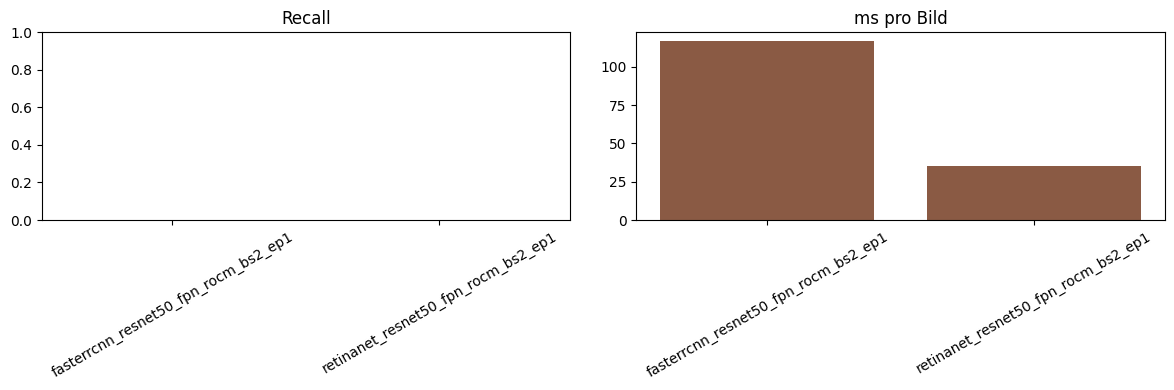

In [8]:
import csv

csv_path = latest_eval_csv()
print("Lade", csv_path)
with csv_path.open(newline="", encoding="utf-8") as fh:
    rows = list(csv.DictReader(fh))

for row in rows:
    row["recall"] = float(row["recall"])
    row["ms_per_image"] = float(row["ms_per_image"])
    row["true_faces"] = int(row["true_faces"])
    row["detected_faces"] = int(row["detected_faces"])

print("model,recall,true_faces,detected_faces,ms_per_image")
for row in rows:
    print(f"{row['model']},{row['recall']:.3f},{row['true_faces']},{row['detected_faces']},{row['ms_per_image']:.1f}")

labels = [Path(row["model"]).stem for row in rows]
recalls = [row["recall"] for row in rows]
speeds = [row["ms_per_image"] for row in rows]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(labels, recalls, color="#2f6f9f")
axes[0].set_title("Recall")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(labels, speeds, color="#8a5a44")
axes[1].set_title("ms pro Bild")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


## Modell-Vorzüge aus der Auswertung

In [9]:
json_files = sorted(RESULTS.glob("evaluation_*.json"), key=lambda p: p.stat().st_mtime)
if not json_files:
    raise FileNotFoundError("Noch keine evaluation_*.json in model_results gefunden.")
json_path = json_files[-1]
print("Lade", json_path)

payload = json.loads(json_path.read_text(encoding="utf-8"))
notes = payload.get("model_notes", {})
for row in payload.get("results", []):
    note = notes.get(row["model"], {})
    print()
    print(row["model"])
    print(f"  Recall: {row['recall']:.3f} | ms/Bild: {row['ms_per_image']:.1f}")
    if note:
        print(f"  Familie: {note.get('family')}")
        print(f"  Vorzug: {note.get('strengths')}")
        print(f"  Achtung: {note.get('watch')}")


Lade /home/clemi/projekte/MIM/model_results/evaluation_20260614_210655.json

fasterrcnn_resnet50_fpn_rocm_bs2_ep1.pth
  Recall: 0.000 | ms/Bild: 116.6
  Familie: Faster R-CNN
  Vorzug: Solide Two-Stage-Qualitätsbaseline; gute Lokalisierung und interpretierbares Training.
  Achtung: Für Video eher langsam und VRAM/CPU-overhead-intensiv.

retinanet_resnet50_fpn_rocm_bs2_ep1.pth
  Recall: 0.000 | ms/Bild: 35.5
  Familie: RetinaNet
  Vorzug: One-Stage-Detector mit Focal Loss; interessant bei vielen einfachen Negativen und kleinen Objekten.
  Achtung: Meist langsamer/umständlicher als YOLO in der Video-Pipeline.
